In [4]:
import torch
import pathlib
from models.graph_learning import HiPoNet, MLPAutoEncoder
from utils.read_data import load_data
import phate
import scprep
import numpy as np

In [22]:
PCs, labels, num_labels = load_data(
    "/home/tl855/project_pi_sk2433/shared/Hiren_2025_HiPoNet/pdo_data/", ""
)
precomputed_embeddings = torch.load(
    "/home/tl855/project_pi_sk2433/tl855/PointCloudNet/data/precomputed_embeddings/pdo_data_emb.pt"
)
precomputed_labels = torch.load(
    "/home/tl855/project_pi_sk2433/tl855/PointCloudNet/data/precomputed_embeddings/pdo_data_label.pt"
)
label_names = np.load("/home/tl855/project_pi_sk2433/shared/Hiren_2025_HiPoNet/pdo_data/labels_pdo_treatment.npy")
# Note: np.unique does not preserve order, but in this case it does since labels appear alphabetically
label_names = np.unique(label_names)

[l.item() for l in labels] == [l.item() for l in precomputed_labels]

True

In [6]:
slurm_job_id = "1973535"
weights = torch.load(f"model_weights/{slurm_job_id}/autoencoder.pt", map_location="cpu")
autoencoder = MLPAutoEncoder(
    input_dim=precomputed_embeddings.shape[1],
    hidden_dim=1024,
    embedding_dim=8,
    num_layers=3,
)
autoencoder.load_state_dict(weights)
with torch.no_grad():
    autoenc_embeddings = autoencoder.encode(precomputed_embeddings)

In [7]:
phate_dim, phate_knn = 2, 25

Calculating PHATE...
  Running PHATE on 1625 observations and 308 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.05 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.07 seconds.
    Calculating affinities...
    Calculated affinities in 0.02 seconds.
  Calculated graph and diffusion operator in 0.15 seconds.
  Calculating optimal t...
    Automatically selected t = 10
  Calculated optimal t in 1.44 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.37 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.69 seconds.
Calculated PHATE in 3.65 seconds.


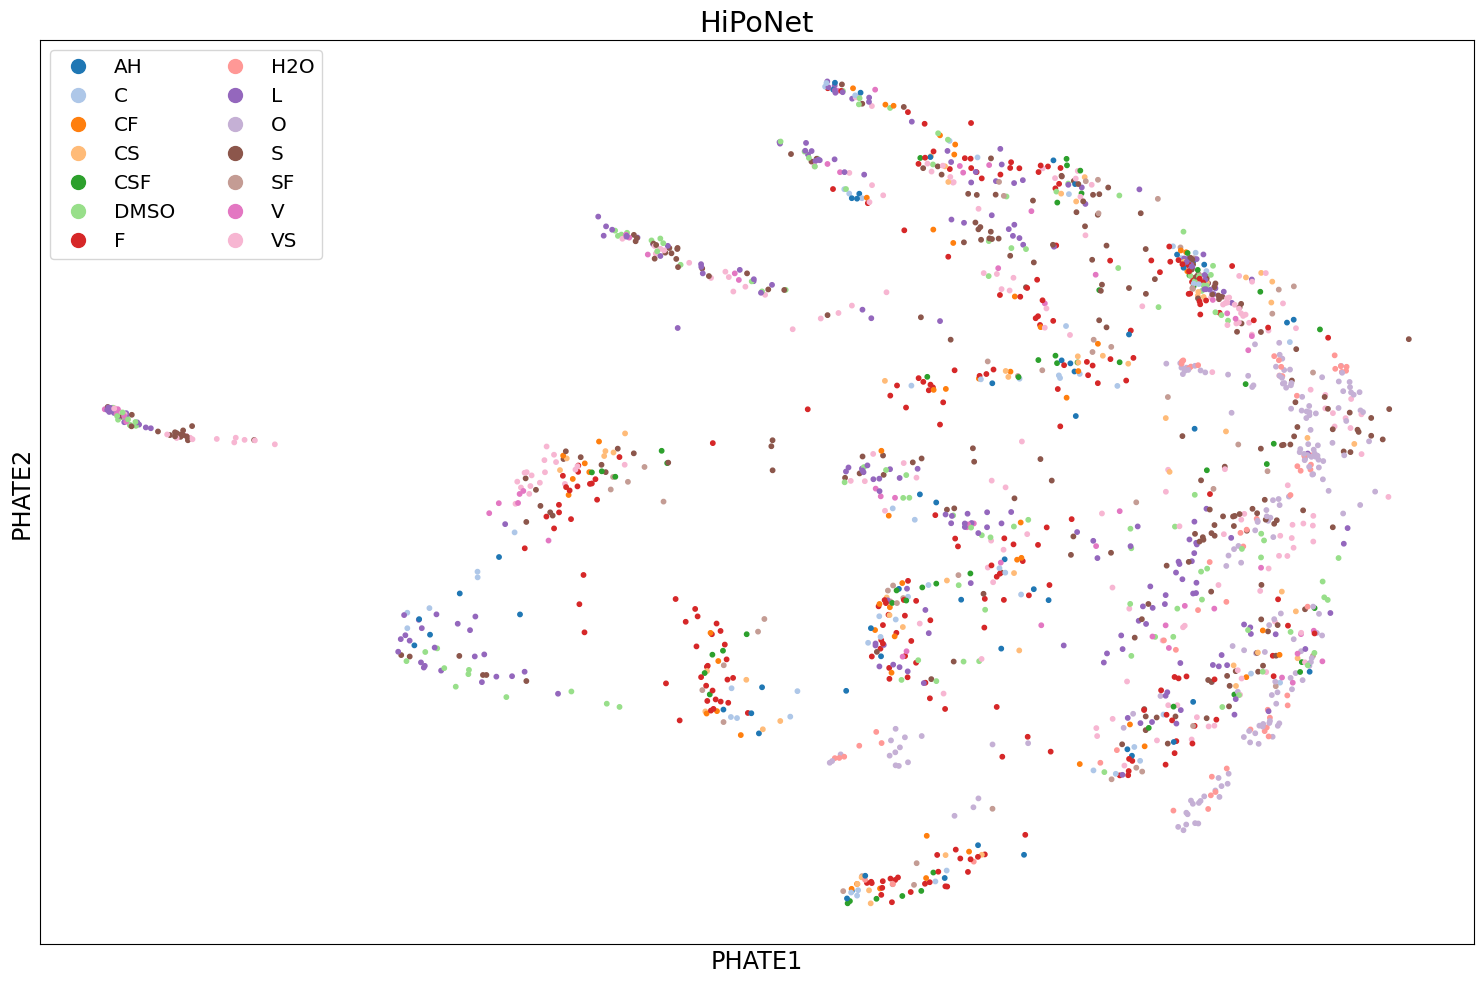

In [26]:
phate_op = phate.PHATE(n_components=phate_dim, knn=phate_knn)
phate_coords = phate_op.fit_transform(precomputed_embeddings)

ax = scprep.plot.scatter2d(
    phate_coords,
    c=[label_names[i] for i in labels],
    cmap="tab20",
    s=10,
    figsize=(15,10),
    ticks=None,
    label_prefix="PHATE",
    fontsize=12,
    legend=True,
    discrete=True,
    title="HiPoNet",
)

Calculating PHATE...
  Running PHATE on 1625 observations and 8 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.09 seconds.
    Calculating affinities...
    Calculated affinities in 0.03 seconds.
  Calculated graph and diffusion operator in 0.12 seconds.
  Calculating optimal t...
    Automatically selected t = 44
  Calculated optimal t in 1.33 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.71 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.25 seconds.
Calculated PHATE in 4.42 seconds.


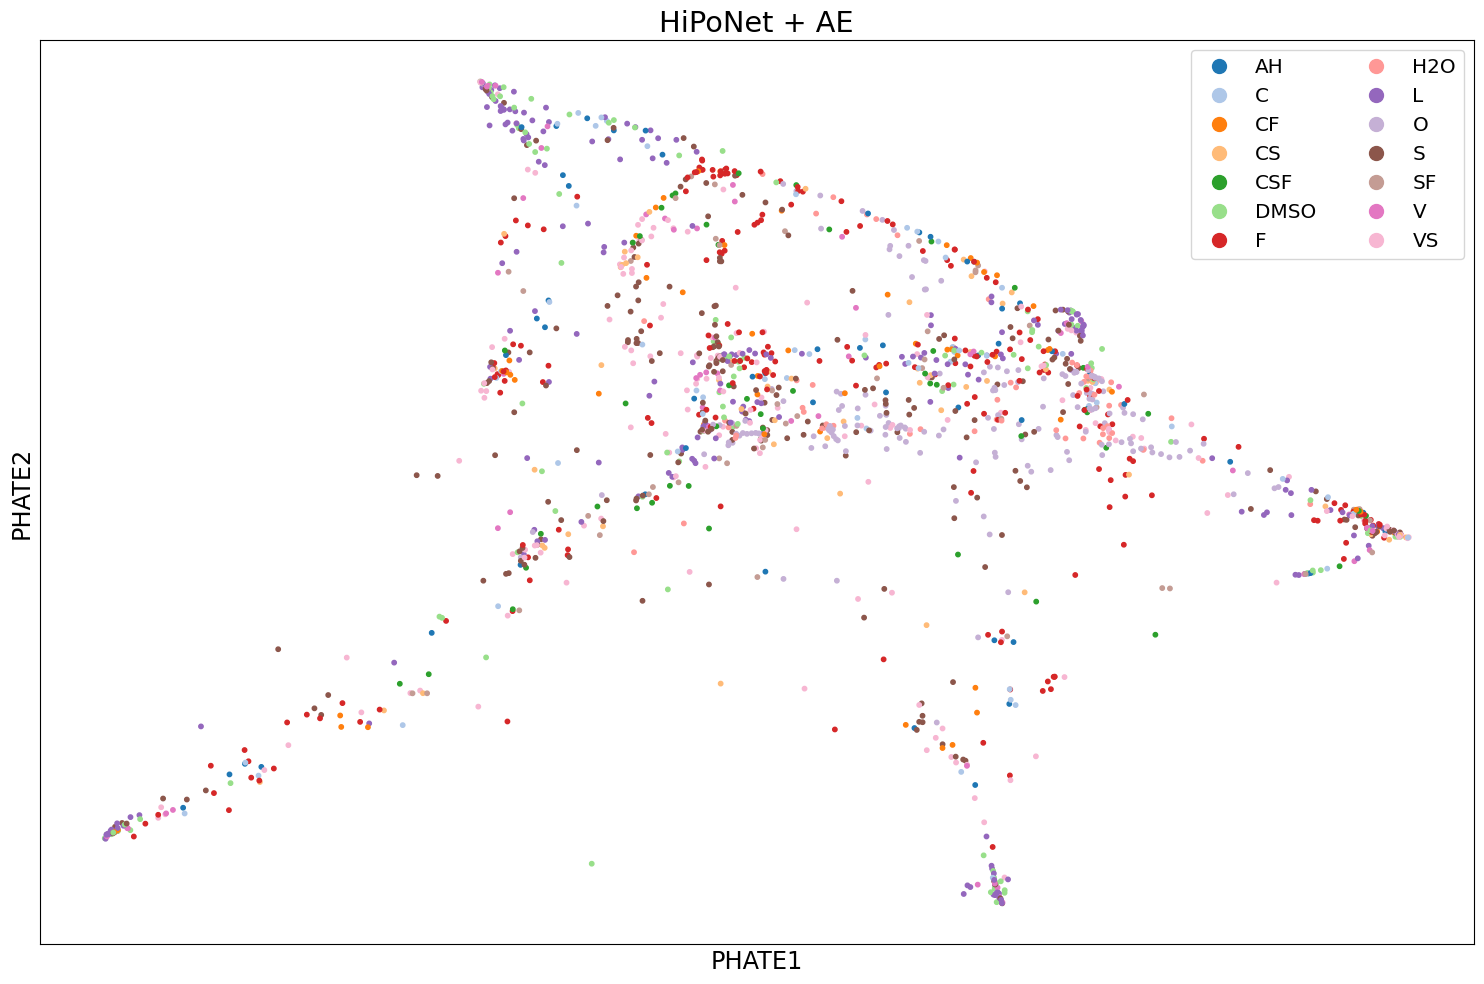

In [27]:
phate_op = phate.PHATE(n_components=3, knn=50)
phate_coords = phate_op.fit_transform(autoenc_embeddings)

ax = scprep.plot.scatter2d(
    phate_coords,
    c=[label_names[i] for i in labels],
    cmap="tab20",
    s=10,
    figsize=(15,10),
    ticks=None,
    label_prefix="PHATE",
    fontsize=12,
    legend=True,
    discrete=True,
    title="HiPoNet + AE",
)